# Tutorial: comparing two samples with `aisource.metrics`

This notebook demonstrates the package's multivariate two-sample metrics on two simple random distributions in two dimensions. We will:

1. draw a **reference** sample and a slightly shifted, differently correlated **generated** sample;
2. inspect both samples visually;
3. calculate the full metric suite with `evaluate`; and
4. call and interpret each metric individually.

All examples use a fixed random seed, so the notebook is reproducible.

## 1. Imports

When this notebook is run from the repository, the setup cell adds `src/` to Python's import path. After installing the package (for example, with `pip install -e .`), the path setup is harmless.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Support running from either the repository root or notebooks/.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = repo_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from aisource.metrics import (
    c2st,
    energy_distance,
    evaluate,
    mmd_rbf,
)

## 2. Generate two 2D samples

Every metric expects arrays shaped `(n_samples, n_features)`. Here each row is one observation and the two columns are the features $x_1$ and $x_2$. The arrays may contain different numbers of rows, but must have the same number of columns.

The reference distribution is a correlated standard Gaussian. The generated distribution has a small mean shift and a different correlation, giving the metrics real—but not extreme—differences to find.

In [14]:
rng = np.random.default_rng(42)
n_samples = 1_000

reference = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=[[1.0, 0.65], [0.65, 1.0]],
    size=n_samples,
)
generated = rng.multivariate_normal(
    mean=[0.35, -0.15],
    cov=[[1.0, 0.20], [0.20, 1.25]],
    size=n_samples,
)

print("reference shape:", reference.shape)
print("generated shape:", generated.shape)
print("reference mean:", reference.mean(axis=0).round(3))
print("generated mean: ", generated.mean(axis=0).round(3))

reference shape: (1000, 2)
generated shape: (1000, 2)
reference mean: [0.081 0.049]
generated mean:  [ 0.373 -0.143]


A scatter plot makes the location and dependence differences visible before we reduce them to summary statistics.

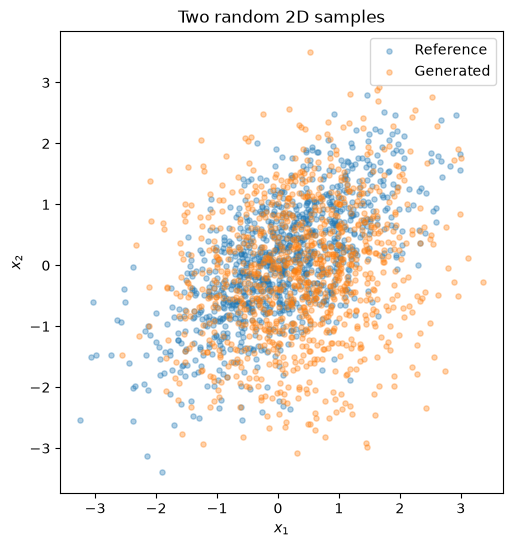

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(reference[:, 0], reference[:, 1], s=14, alpha=0.35, label="Reference")
ax.scatter(generated[:, 0], generated[:, 1], s=14, alpha=0.35, label="Generated")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Two random 2D samples")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.show()

## 3. Compute the complete metric suite

`evaluate` is the simplest entry point. It computes the complete metric suite on the feature vectors. The `seed` controls subsampling and cross-validation, while `max_samples` bounds the quadratic cost of MMD and energy distance.

In [16]:
results = evaluate(reference, generated, seed=17, max_samples=1_000)

for name, value in results.items():
    print(f"{name:22s} {value:.6g}")

mmd_rbf_squared        0.0241832
c2st_accuracy          0.5985
c2st_roc_auc           0.617823
c2st_pvalue            5.92828e-19
energy_distance        0.278442


How to read the output:

| Output | Desired value when distributions match | What it detects |
|---|---:|---|
| `mmd_rbf_squared` | near 0 | General distribution differences through an RBF kernel |
| `c2st_accuracy`, `c2st_roc_auc` | near 0.5 | Differences a chosen classifier can learn |
| `c2st_pvalue` | not small | Evidence that classifier accuracy is above chance |
| `energy_distance` | near 0 | General multivariate distribution differences |

These are sample estimates, so even two draws from the same distribution will not produce exact ideal values. There is also no universal cutoff for MMD or energy distance: compare models using the same preprocessing, seed, sample limit, and feature order.

## 4. Use each metric directly

Calling the functions separately gives access to metric-specific options.

### RBF maximum mean discrepancy (MMD²)

MMD compares samples through a kernel. Lower values indicate greater similarity. By default, the implementation standardizes the pooled features and selects the RBF bandwidth with the median-distance heuristic. The unbiased estimate can be slightly negative from finite-sample noise.

In [17]:
mmd_default = mmd_rbf(reference, generated, seed=17)
mmd_fixed_bandwidth = mmd_rbf(reference, generated, bandwidth=1.0, seed=17)

print(f"MMD² (automatic bandwidth): {mmd_default:.6f}")
print(f"MMD² (bandwidth = 1.0):    {mmd_fixed_bandwidth:.6f}")

MMD² (automatic bandwidth): 0.024183
MMD² (bandwidth = 1.0):    0.030897


### Classifier two-sample test (C2ST)

C2ST labels reference rows as 0 and generated rows as 1, then obtains out-of-fold predictions from balanced samples. Accuracy and ROC AUC near 0.5 mean that this classifier cannot tell them apart. A small one-sided binomial p-value indicates above-chance classification, but does not measure the size of the distribution difference.

Logistic regression is fast and detects linearly separable differences. Use `classifier="random_forest"` when nonlinear or dependence differences matter, and keep the classifier fixed across comparisons.

In [18]:
linear_c2st = c2st(reference, generated, classifier="logistic", folds=5, seed=17)
forest_c2st = c2st(reference, generated, classifier="random_forest", folds=5, seed=17)

print("Logistic regression:", {k: round(v, 4) for k, v in linear_c2st.items()})
print("Random forest:      ", {k: round(v, 4) for k, v in forest_c2st.items()})

Logistic regression: {'accuracy': 0.5985, 'roc_auc': 0.6178, 'pvalue': 0.0}
Random forest:       {'accuracy': 0.5885, 'roc_auc': 0.6286, 'pvalue': 0.0}


### Energy distance

Energy distance is zero only for identical population distributions. Its sample estimate is nonnegative, and lower is better. As with MMD, pooled standardization is enabled by default so a feature does not dominate only because it uses larger units.

In [19]:
distance = energy_distance(reference, generated, seed=17)
print(f"Energy distance: {distance:.6f}")

Energy distance: 0.278442


## 5. Add a same-distribution baseline

Raw distance values are easier to understand beside a baseline. Below, a fresh sample from the reference distribution is compared with the original reference sample. Its metrics should generally be closer to their ideal values than those for the deliberately altered generated distribution.

In [20]:
matching = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=[[1.0, 0.65], [0.65, 1.0]],
    size=n_samples,
)
baseline = evaluate(reference, matching, seed=17, max_samples=1_000)

print(f"{'metric':22s} {'same distribution':>18s} {'altered distribution':>21s}")
for name in results:
    print(f"{name:22s} {baseline[name]:18.6g} {results[name]:21.6g}")

metric                  same distribution  altered distribution
mmd_rbf_squared                0.00152472             0.0241832
c2st_accuracy                       0.514                0.5985
c2st_roc_auc                     0.518539              0.617823
c2st_pvalue                      0.109374           5.92828e-19
energy_distance                 0.0925193              0.278442
